**U-net network for image segmentation** 

In [20]:
#!pip install imagecodecs
#!pip install --upgrade tifffile imagecodecs

In [21]:
import tensorflow as tf
import glob
import os
import numpy as np

**Encoder**

In [ ]:
import tensorflow as tf

def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    
    return x

**Decoder**

In [ ]:
def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)

    #skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(skip_features)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

**Defining the Unet model**

In [24]:
def unet_model(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Contracting Path (Encoder)
    s1 = encoder_block(inputs, 64)
    s2 = encoder_block(s1, 128)
    s3 = encoder_block(s2, 256)
    s4 = encoder_block(s3, 512)
    
    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='valid')(s4)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='valid')(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    
    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='valid', activation='sigmoid')(d4)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

if __name__ == '__main__':
    model = unet_model(input_shape=(512, 512, 3), num_classes=1)
    model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 510, 510,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 510, 510,  │          0 │ conv2d_19[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 508, 508,  │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 508, 508,  │          0 │ conv2d_20[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 254, 254,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 252, 252,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 252, 252,  │          0 │ conv2d_21[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 250, 250,  │    147,584 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 250, 250,  │          0 │ conv2d_22[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 125, 125,  │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 123, 123,  │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 123, 123,  │          0 │ conv2d_23[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 121, 121,  │    590,080 │ activation_22[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 121, 121,  │          0 │ conv2d_24[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 60, 60,    │          0 │ activation_23[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 58, 58,    │  1,180,160 │ max_pooling2d_6[

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

**data loading**

**Load paths**

In [25]:
import os
import glob

ROOT = "/kaggle/input/datasets/cedricniango"

IMAGE_DIR = os.path.join(ROOT, "dir-01-png")
MASK_DIR  = os.path.join(ROOT, "01-gt-seg-png")


def get_dataset_paths(image_dir, mask_dir):

    image_paths = sorted(glob.glob(os.path.join(image_dir, "t*.png")))

    mask_files = set(os.listdir(mask_dir))

    image_list = []
    mask_list = []

    for img_path in image_paths:

        name = os.path.basename(img_path)
        idx = ''.join(filter(str.isdigit, name))

        mask_name = f"man_seg{idx}.png"

        if mask_name in mask_files:
            image_list.append(img_path)
            mask_list.append(os.path.join(mask_dir, mask_name))

    print(f"Matched pairs: {len(image_list)}")

    return image_list, mask_list

**Image Preprocessing and mask** 

In [26]:
import imageio.v2 as imageio
#import tifffile as tiff
import tensorflow as tf
import numpy as np

IMG_SIZE = 512

def load_sample(img_path, mask_path):

    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=1)

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.cast(mask > 0, tf.float32)

    return img, mask

**Data augmentation**

In [27]:
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    return img, mask

**Dataset creation**

In [28]:
def create_dataset(image_paths, mask_paths, batch_size=8, augment_data=True):

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    dataset = dataset.map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment_data:
        dataset = dataset.map(
            augment,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.shuffle(100)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

**Usage**

In [29]:
ROOT = "DIC-C2DH-HeLa"
IMAGE_DIR = "/kaggle/input/datasets/cedricniango/dir-01-png"
MASK_DIR = "/kaggle/input/datasets/cedricniango/01-gt-seg-png"

IMAGE_DIR_test = "/kaggle/input/datasets/cedricniango/dir-02-png"
MASK_DIR_test = "/kaggle/input/datasets/cedricniango/02-gt-seg-png"

train_img, train_mask = get_dataset_paths(IMAGE_DIR, MASK_DIR)
test_img, test_mask = get_dataset_paths(IMAGE_DIR_test, MASK_DIR_test)

train_dataset = create_dataset(train_img, train_mask, batch_size=4, augment_data=True)
test_dataset  = create_dataset(test_img, test_mask, batch_size=4, augment_data=False)

Matched pairs: 9
Matched pairs: 9


**VERIFICATION**

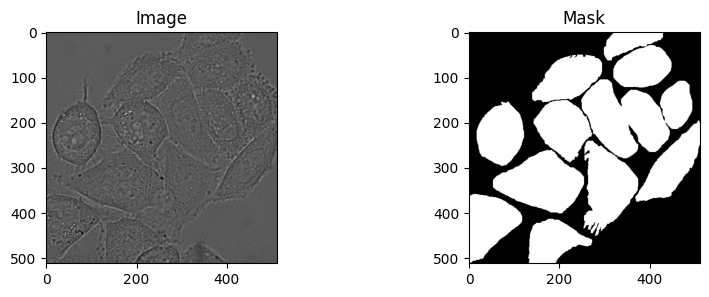

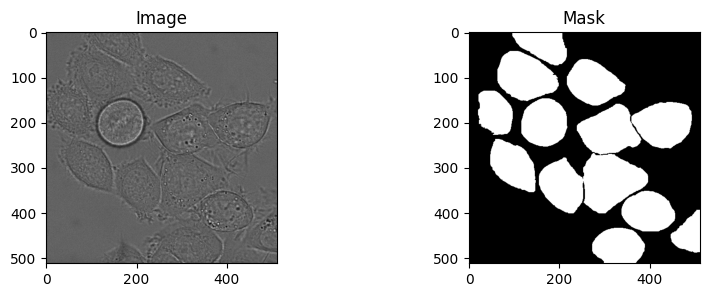

In [34]:
import matplotlib.pyplot as plt

def show_sample(ds):
    for img, mask in ds.take(2):
        plt.figure(figsize=(10,3))

        plt.subplot(1,2,1)
        plt.title("Image")
        plt.imshow(img[0,...,0], cmap='gray')

        plt.subplot(1,2,2)
        plt.title("Mask")
        plt.imshow(mask[0,...,0], cmap='gray')

        plt.show()

show_sample(train_dataset)

**TRAINING AND LOSS FUNCTION**

*Loss function*

In [ ]:
# Loss BCE (Binary cross-entropy): https://softwaremill.com/instance-segmentation-loss-functions/
# Loss Dice : https://www.tensorflow.org/api_docs/python/tf/keras/losses/Dice
def dice_loss(y_true, y_pred, epsi=1e-7):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    #epsi = 1e-7
    return 1 - (2 * tf.reduce_sum(y_true * y_pred)) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + epsi) #Intersection / Union


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return bce + d_loss

**Compile model**

IMAGE_SIZE = 512
model = unet_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1), num_classes=1)

model.compile(optimizer=tf.keras.optimizer.Adam(learning_rate=1e-4),
             loss=dice_loss,
             metrics=["accuracy"]
             )